In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
import gymnasium as gym

In [2]:
class PolicyNet(nn.Module):
    def __init__(self, state_dim, hidden_dim, action_dim):
        super().__init__()
        self.fc1 = nn.Linear(state_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, action_dim)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        return F.softmax(self.fc2(x), -1)

In [3]:
class ValueNet(nn.Module):
    def __init__(self, state_dim, hidden_dim):
        super().__init__()
        self.fc1 = nn.Linear(state_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        return self.fc2(x)

In [4]:
class ActorCritic:
    def __init__(self, state_dim, hidden_dim, action_dim, actor_lr, critic_lr, gamma, device):
        self.actor = PolicyNet(state_dim, hidden_dim, action_dim).to(device)
        self.critic = ValueNet(state_dim, hidden_dim).to(device)

        self.actor_optimizer = torch.optim.Adam(self.actor.parameters(), lr=actor_lr)
        self.critic_optimizer = torch.optim.Adam(self.critic.parameters(), lr=critic_lr)

        self.gamma = gamma
        self.device = device

    def take_action(self, state):
        state = torch.tensor(state, dtype=torch.float).to(self.device)
        action_probs = self.actor(state)
        action_distribution = torch.distributions.Categorical(action_probs)
        return action_distribution.sample().item()

    def update(self, transition_dict):
        states = torch.tensor(np.array(transition_dict['states']), dtype=torch.float).to(self.device)
        actions = torch.tensor(transition_dict['actions']).view(-1, 1).to(self.device)
        rewards = torch.tensor(transition_dict['rewards'], dtype=torch.float).view(-1, 1).to(self.device)
        next_states = torch.tensor(np.array(transition_dict['next_states']), dtype=torch.float).to(self.device)
        terminated = torch.tensor(transition_dict['terminated'], dtype=torch.float).view(-1, 1).to(self.device)

        td_targets = rewards + self.gamma * self.critic(next_states) * (1 - terminated)
        td_error = td_targets - self.critic(states)
        log_probs = torch.log(self.actor(states).gather(1, actions))

        actor_loss = torch.mean(-log_probs * td_error.detach())
        critic_loss = F.mse_loss(td_targets.detach(), self.critic(states))

        self.actor_optimizer.zero_grad()
        self.critic_optimizer.zero_grad()
        actor_loss.backward()
        critic_loss.backward()
        self.actor_optimizer.step()
        self.critic_optimizer.step()

In [5]:
num_episodes = 1000
actor_lr = 1e-3
critic_lr = 1e-2
gamma = 0.98
hidden_dim = 128
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('mps') if torch.backends.mps.is_available() else torch.device('cpu')

env = gym.make('CartPole-v1')
state_dim = env.observation_space.shape[0]
action_dim = env.action_space.n

env.reset(seed = 0)
torch.manual_seed(0)
np.random.seed(0)

agent = ActorCritic(state_dim, hidden_dim, action_dim, actor_lr, critic_lr, gamma, device)
return_list = []

for i in range(10):
    with tqdm(total=num_episodes // 10, desc='Iteration %d' % i) as pbar:
        for i_episode in range(num_episodes // 10):
            episode_return = 0
            transition_dict = {'states': [], 'actions': [], 'rewards': [], 'next_states': [], 'terminated': []}

            state, info = env.reset()
            while True:
                action = agent.take_action(state)
                next_state, reward, terminated, truncated, info = env.step(action)

                transition_dict['states'].append(state)
                transition_dict['actions'].append(action)
                transition_dict['rewards'].append(reward)
                transition_dict['next_states'].append(next_state)
                transition_dict['terminated'].append(terminated)

                episode_return += reward
                state = next_state
                if terminated or truncated:
                    break

            agent.update(transition_dict)
            return_list.append(episode_return)

            if (i_episode + 1) % 10 == 0:
                pbar.set_postfix({
                    'episode': '%d' % (num_episodes / 10 * i + i_episode + 1),
                    'return': '%.3f' % np.mean(return_list[-10:])
                })
            pbar.update(1)


Iteration 9: 100%|██████████| 100/100 [01:38<00:00,  1.01it/s, episode=1000, return=500.000]


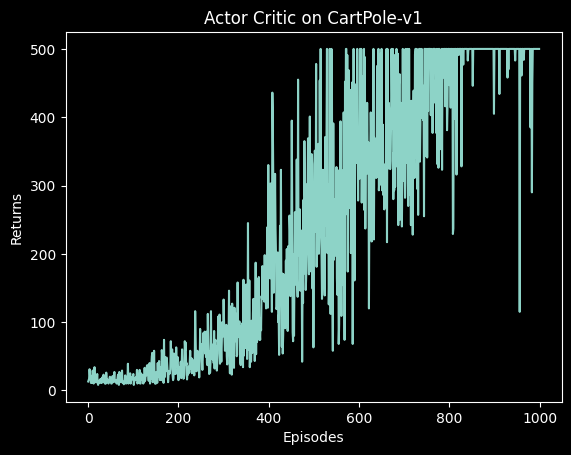

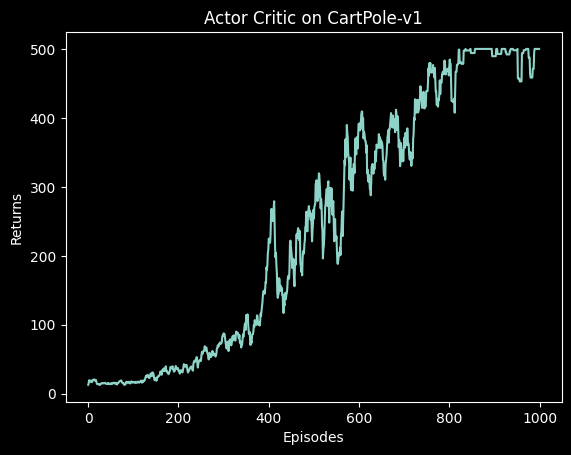

In [6]:
episode_list = list(range(len(return_list)))
plt.plot(episode_list, return_list)
plt.xlabel('Episodes')
plt.ylabel('Returns')
plt.title('Actor Critic on CartPole-v1')
plt.show()

def moving_average(a, window_size):
    cumulative_sum = np.cumsum(np.insert(a, 0, 0))
    middle = (cumulative_sum[window_size:] - cumulative_sum[:-window_size]) / window_size

    r = np.arange(1, window_size, 2)
    begin = np.cumsum(a[:window_size-1])[::2] / r
    end = (np.cumsum(a[:-window_size:-1])[::2] / r)[::-1]
    return np.concatenate((begin, middle, end))

mv_return = moving_average(return_list, 9)
plt.plot(episode_list, mv_return)
plt.xlabel('Episodes')
plt.ylabel('Returns')
plt.title('Actor Critic on CartPole-v1')
plt.show()
